In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df=pd.read_csv("wine_data.csv",header=None,usecols=[0,1,2])
df.columns=["Class label","Alcohol","Malic acid"]

In [9]:
df.sample(5)

,Class label,Alcohol,Malic acid
31,1,13.58,1.66
153,3,13.23,3.30
140,3,12.93,2.81
112,2,11.76,2.68
174,3,13.40,3.91


<Axes: xlabel='Alcohol', ylabel='Density'>

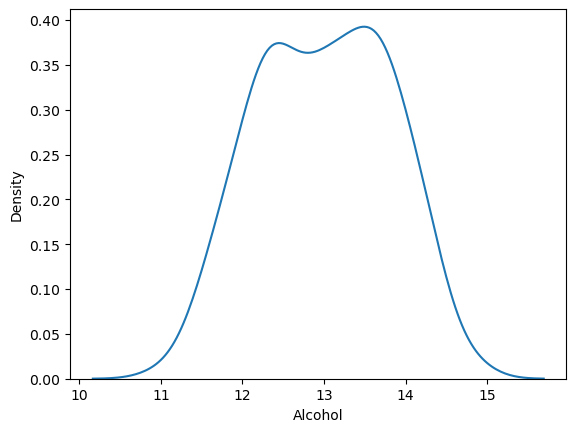

In [10]:
sns.kdeplot(df["Alcohol"])

<Axes: xlabel='Malic acid', ylabel='Density'>

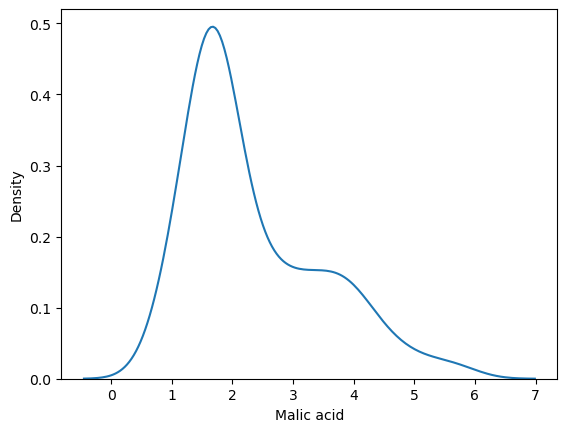

In [11]:
sns.kdeplot(df["Malic acid"])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

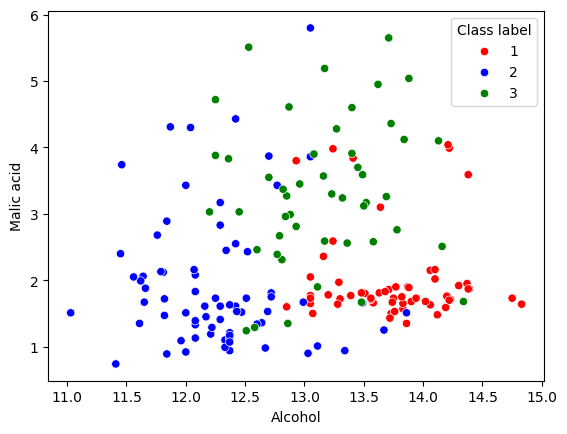

In [15]:
color_dict={1:"red",3:"green",2:"blue"}
sns.scatterplot(x=df["Alcohol"],y=df["Malic acid"],hue=df["Class label"],palette=color_dict)

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop("Class label",axis=1),
                                               df["Class label"],
                                               test_size=0.3,random_state=0)
x_train.shape, x_test.shape

((124, 2), (54, 2))

In [17]:
from sklearn.preprocessing import MinMaxScaler


In [21]:
scaler=MinMaxScaler()

#fill the scaler to the train set, it will learn the parameter
scaler.fit(x_train)

#transform
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [22]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [24]:
np.round(x_train.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [25]:
np.round(x_train_scaled.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


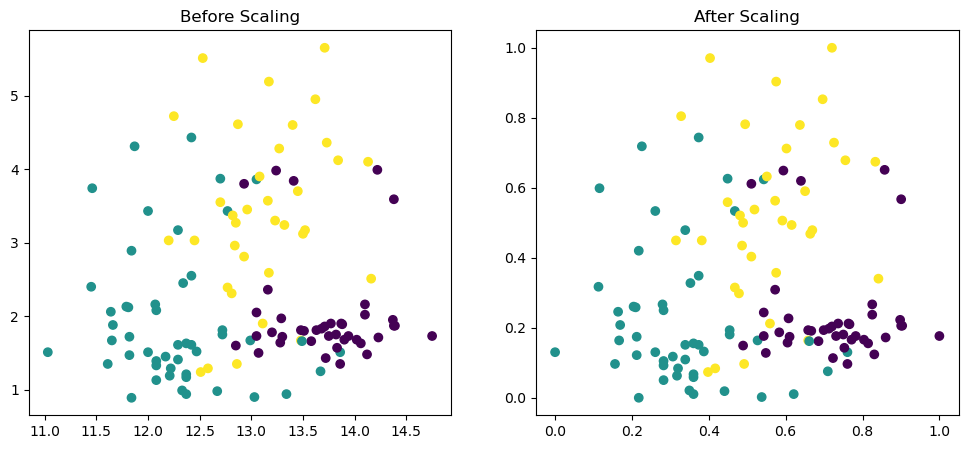

In [30]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(x_train["Alcohol"],x_train["Malic acid"],c=y_train)
ax1.set_title("Before Scaling")

ax2.scatter(x_train_scaled["Alcohol"],x_train_scaled["Malic acid"],c=y_train)
ax2.set_title("After Scaling")
plt.show()

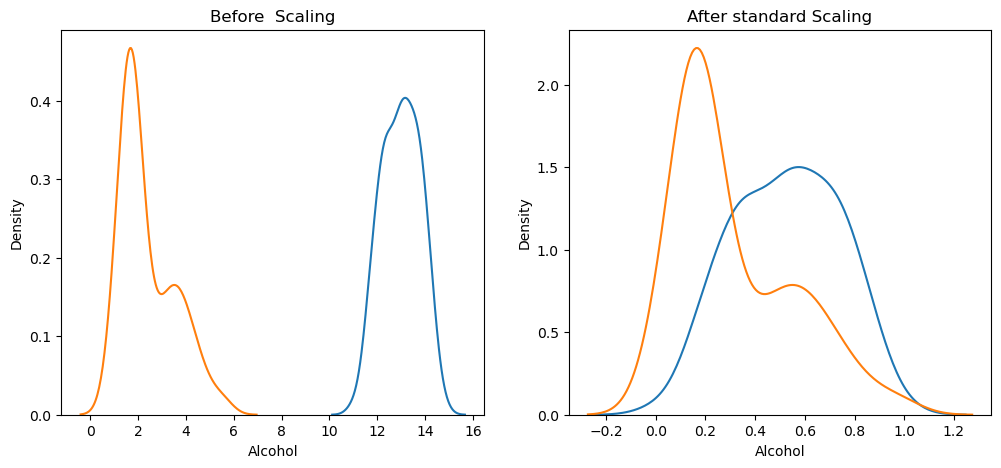

In [34]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

##before Scaling
sns.kdeplot(x_train["Alcohol"],ax=ax1)
sns.kdeplot(x_train["Malic acid"],ax=ax1)
ax1.set_title("Before  Scaling")


##after scaling
sns.kdeplot(x_train_scaled["Alcohol"],ax=ax2)
sns.kdeplot(x_train_scaled["Malic acid"],ax=ax2)
ax2.set_title("After standard Scaling")
plt.show()

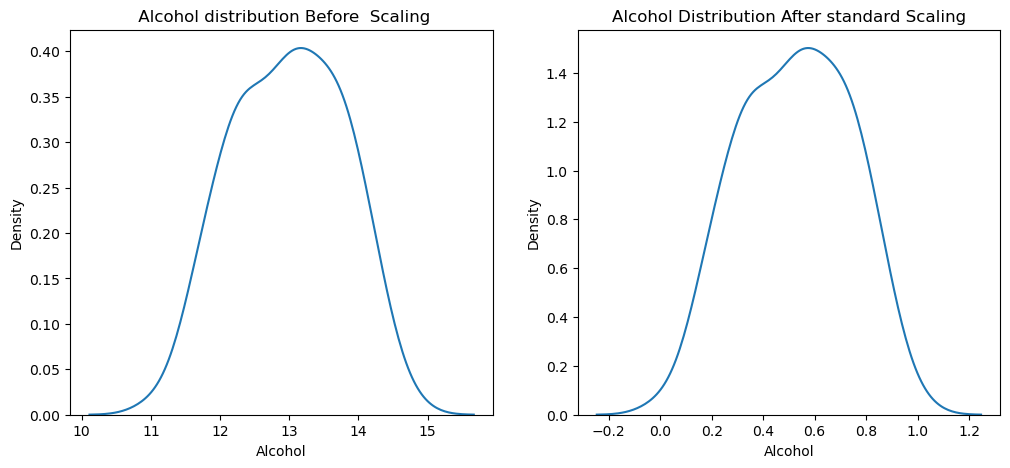

In [35]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

##before Scaling
sns.kdeplot(x_train["Alcohol"],ax=ax1)
ax1.set_title(" Alcohol distribution Before  Scaling")


##after scaling
sns.kdeplot(x_train_scaled["Alcohol"],ax=ax2)
ax2.set_title("Alcohol Distribution After standard Scaling")
plt.show()

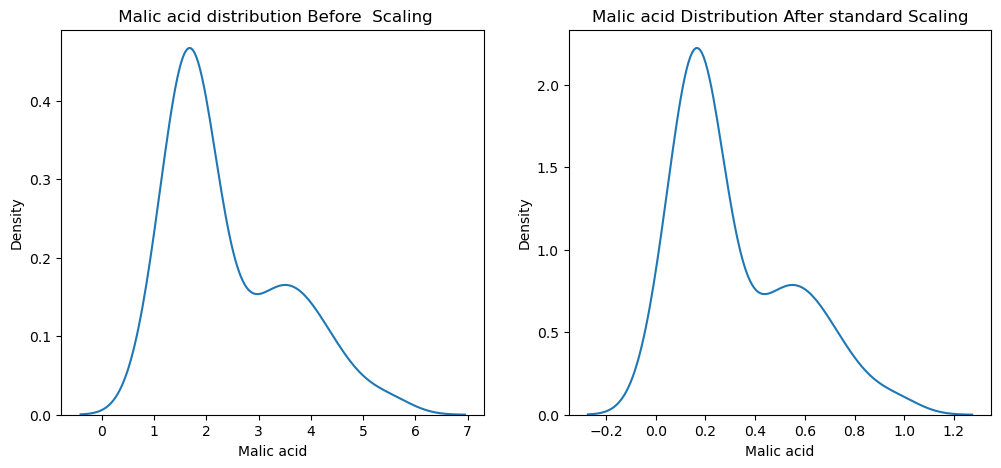

In [36]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

##before Scaling
sns.kdeplot(x_train["Malic acid"],ax=ax1)
ax1.set_title(" Malic acid distribution Before  Scaling")


##after scaling
sns.kdeplot(x_train_scaled["Malic acid"],ax=ax2)
ax2.set_title("Malic acid Distribution After standard Scaling")
plt.show()